In [1]:
# 📂 Load All Processed DataFrames for Y Value Preparation
# Load all saved dataframes from /data/dataframes/ directory

import pandas as pd
import numpy as np
from pathlib import Path

print("📂 Loading processed dataframes for 2D spectrum Y preparation...")

# Define dataframes directory path
dataframes_dir = Path('../data/dataframes')

# Check if directory exists
if not dataframes_dir.exists():
    print(f"❌ Directory not found: {dataframes_dir}")
    print("   Make sure to run the data engineering pipeline first!")
else:
    print(f"📁 Loading from: {dataframes_dir.absolute()}")
    
    # Find all pickle files in the directory
    pkl_files = list(dataframes_dir.glob("*.pkl"))
    
    if not pkl_files:
        print("❌ No pickle files found in directory!")
    else:
        print(f"🎯 Found {len(pkl_files)} pickle files to load")
        
        # Load each dataframe
        loaded_count = 0
        failed_count = 0
        total_size_mb = 0
        loaded_dataframes = []
        
        print(f"\n📂 Loading dataframes...")
        
        for pkl_file in sorted(pkl_files):
            try:
                # Extract dataframe name from filename (remove .pkl extension)
                df_name = pkl_file.stem
                
                # Load dataframe from pickle
                df = pd.read_pickle(pkl_file)
                
                # Create variable in global namespace
                globals()[df_name] = df
                
                # Get file size
                file_size_mb = pkl_file.stat().st_size / (1024 * 1024)
                total_size_mb += file_size_mb
                
                loaded_count += 1
                loaded_dataframes.append(df_name)
                
                print(f"  ✅ {df_name} ({file_size_mb:.2f} MB) - Shape: {df.shape}")
                
            except Exception as e:
                failed_count += 1
                print(f"  ❌ {pkl_file.name}: Error - {str(e)}")
        
        print(f"\n✅ Dataframe loading completed!")
        print(f"   📊 Total files found: {len(pkl_files)}")
        print(f"   ✅ Successfully loaded: {loaded_count}")
        print(f"   ❌ Failed to load: {failed_count}")
        print(f"   💽 Total size loaded: {total_size_mb:.2f} MB")
        
        # Show breakdown for Y preparation context
        if loaded_dataframes:
            print(f"\n📋 Dataframes for 2D Spectrum Y Preparation:")
            
            # Expected file types and stations
            file_types = ['met', 'den', 'dir1', 'dir2', 'r1', 'r2']
            target_stations = ['51028', '41008']
            
            # Focus on spectral data for Y values
            spectral_types = ['den', 'dir1', 'dir2', 'r1', 'r2']
            
            print(f"🌊 Spectral data available:")
            for file_type in spectral_types:
                type_dfs = [df for df in loaded_dataframes if df.startswith(f'{file_type}_')]
                if type_dfs:
                    # Count by station
                    station_counts = {}
                    for station in target_stations:
                        station_count = len([df for df in type_dfs if station in df])
                        if station_count > 0:
                            station_counts[station] = station_count
                    
                    if station_counts:
                        station_summary = ', '.join([f"Station {s}: {c}" for s, c in station_counts.items()])
                        print(f"  {file_type}: {len(type_dfs)} files ({station_summary})")
            
            print(f"\n📈 Meteorological data available:")
            met_dfs = [df for df in loaded_dataframes if df.startswith('met_')]
            if met_dfs:
                station_counts = {}
                for station in target_stations:
                    station_count = len([df for df in met_dfs if station in df])
                    if station_count > 0:
                        station_counts[station] = station_count
                
                station_summary = ', '.join([f"Station {s}: {c}" for s, c in station_counts.items()])
                print(f"  met: {len(met_dfs)} files ({station_summary})")
        
        print(f"\n🎯 Ready to prepare 2D spectrum Y values!")
        print(f"   Available for processing: den, dir1, dir2, r1, r2 dataframes")
        print(f"   Stations: 51028, 41008")


📂 Loading processed dataframes for 2D spectrum Y preparation...
📁 Loading from: d:\projects\FYP-OCNWVS\notebooks\..\data\dataframes
🎯 Found 126 pickle files to load

📂 Loading dataframes...
  ✅ den_41008_2006 (0.28 MB) - Shape: (739, 48)
  ✅ den_41008_2007 (3.21 MB) - Shape: (8650, 48)
  ✅ den_41008_2008 (3.21 MB) - Shape: (8650, 48)
  ✅ den_41008_2009 (1.21 MB) - Shape: (3250, 48)
  ✅ den_41008_2013 (2.98 MB) - Shape: (8041, 48)
  ✅ den_41008_2014 (3.12 MB) - Shape: (8406, 48)
  ✅ den_41008_2015 (3.21 MB) - Shape: (8644, 48)
  ✅ den_41008_2016 (2.28 MB) - Shape: (6151, 48)
  ✅ den_41008_2017 (3.19 MB) - Shape: (8583, 48)
  ✅ den_41008_2018 (3.20 MB) - Shape: (8613, 48)
  ✅ den_41008_2019 (3.19 MB) - Shape: (8586, 48)
  ✅ den_41008_2020 (3.18 MB) - Shape: (8580, 48)
  ✅ den_41008_2021 (3.15 MB) - Shape: (8490, 48)
  ✅ den_41008_2022 (3.21 MB) - Shape: (8655, 48)
  ✅ den_41008_2023 (1.98 MB) - Shape: (5322, 48)
  ✅ den_41008_2024 (0.68 MB) - Shape: (1825, 48)
  ✅ den_41008_2025 (0.67 MB

In [2]:
# 🌊 Create 2D Wave Spectrum using Proper Oceanographic Formula
# D(f,θ) = (1/π) * [0.5 + r1*cos(θ-dir1) + r2*cos(2*(θ-dir2))]
# Y(f,θ) = den(f) × D(f,θ)

import warnings
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

print("🌊 Creating 2D wave spectrum using oceanographic formula...")

# Define target stations and required spectral data
target_stations = ['51028', '41008']
spectral_types = ['den', 'dir1', 'dir2', 'r1', 'r2']  # All 5 components needed

# Define fixed directional grid: 0°, 10°, 20°, ..., 350° (36 bins)
direction_bins = np.arange(0, 360, 10)  # [0, 10, 20, ..., 350]
direction_bins_rad = np.deg2rad(direction_bins)  # Convert to radians
n_directions = len(direction_bins)

print(f"🎯 Directional grid: {n_directions} bins from {direction_bins[0]}° to {direction_bins[-1]}°")

# Get frequency bands from a sample spectral dataframe
sample_spectral_df = None
for df_name in loaded_dataframes:
    if df_name.startswith('den_'):
        sample_spectral_df = globals()[df_name]
        break

if sample_spectral_df is None:
    print("❌ No spectral density dataframes found!")
else:
    # Extract frequency columns (exclude timekey)
    freq_columns = [col for col in sample_spectral_df.columns if col != 'timekey']
    n_freqs = len(freq_columns)
    
    print(f"🎯 Found {n_freqs} frequency bands: {freq_columns[0]} to {freq_columns[-1]}")
    
    # Find all station-year combinations that have ALL required spectral components
    station_year_combinations = set()
    for df_name in loaded_dataframes:
        if any(df_name.startswith(f'{st}_') for st in spectral_types):
            parts = df_name.split('_')
            if len(parts) >= 3:
                station = parts[1]
                year = parts[2]
                if station in target_stations:
                    station_year_combinations.add((station, year))
    
    station_year_combinations = sorted(list(station_year_combinations))
    print(f"\n🎯 Processing {len(station_year_combinations)} station-year combinations:")
    for station, year in station_year_combinations:
        print(f"   Station {station}, Year {year}")
    
    # Create 2D spectrum for each station-year combination
    created_spectra = 0
    failed_spectra = 0
    
    print(f"\n🌊 Creating 2D spectra using oceanographic formula...")
    
    for station, year in station_year_combinations:
        try:
            print(f"  📍 Processing Station {station}, Year {year}...")
            
            # Get ALL required dataframes for this station-year
            den_name = f"den_{station}_{year}"
            dir1_name = f"dir1_{station}_{year}"
            dir2_name = f"dir2_{station}_{year}"
            r1_name = f"r1_{station}_{year}"
            r2_name = f"r2_{station}_{year}"
            
            # Check if all required dataframes exist
            missing_dfs = []
            required_dfs = [den_name, dir1_name, dir2_name, r1_name, r2_name]
            for df_name in required_dfs:
                if df_name not in globals():
                    missing_dfs.append(df_name)
            
            if missing_dfs:
                print(f"    ⚠️ Missing dataframes: {missing_dfs}")
                failed_spectra += 1
                continue
                
            # Load all spectral dataframes
            den_df = globals()[den_name]
            dir1_df = globals()[dir1_name]
            dir2_df = globals()[dir2_name]
            r1_df = globals()[r1_name]
            r2_df = globals()[r2_name]
            
            # Verify they have the same number of rows
            lengths = [len(den_df), len(dir1_df), len(dir2_df), len(r1_df), len(r2_df)]
            if not all(l == lengths[0] for l in lengths):
                print(f"    ❌ Mismatched row counts: den({lengths[0]}), dir1({lengths[1]}), dir2({lengths[2]}), r1({lengths[3]}), r2({lengths[4]})")
                failed_spectra += 1
                continue
            
            # Verify they have the same timekeys (should be aligned from preprocessing)
            timekey_check = (den_df['timekey'].equals(dir1_df['timekey']) and 
                           den_df['timekey'].equals(dir2_df['timekey']) and
                           den_df['timekey'].equals(r1_df['timekey']) and
                           den_df['timekey'].equals(r2_df['timekey']))
            
            if not timekey_check:
                print(f"    ❌ Mismatched timekeys")
                failed_spectra += 1
                continue
            
            n_times = len(den_df)
            
            # Extract spectral data (excluding timekey)
            den_data = den_df[freq_columns].values    # [time, freq] - spectral density
            dir1_data = dir1_df[freq_columns].values  # [time, freq] - primary direction
            dir2_data = dir2_df[freq_columns].values  # [time, freq] - secondary direction
            r1_data = r1_df[freq_columns].values      # [time, freq] - spreading coefficient 1
            r2_data = r2_df[freq_columns].values      # [time, freq] - spreading coefficient 2
            
            # Convert directions to radians
            dir1_rad = np.deg2rad(dir1_data)
            dir2_rad = np.deg2rad(dir2_data)
            
            # Initialize 2D spectrum array: [time, frequency, direction]
            spectrum_2d = np.zeros((n_times, n_freqs, n_directions))
            
            print(f"    🔄 Computing 2D spectrum: {n_times} times × {n_freqs} freqs × {n_directions} dirs")
            
            # Step 1-5: For each time step and frequency, compute 2D spectrum
            for t in range(n_times):
                for f in range(n_freqs):
                    # Get values for this time and frequency
                    den_val = den_data[t, f]
                    dir1_val = dir1_rad[t, f]
                    dir2_val = dir2_rad[t, f]
                    r1_val = r1_data[t, f]
                    r2_val = r2_data[t, f]
                    
                    # Skip if any value is NaN
                    if np.isnan([den_val, dir1_val, dir2_val, r1_val, r2_val]).any():
                        spectrum_2d[t, f, :] = np.nan
                        continue
                    
                    # Step 2: Compute directional distribution D(f,θ) for all directions
                    # D(f,θ) = (1/π) * [0.5 + r1*cos(θ-dir1) + r2*cos(2*(θ-dir2))]
                    
                    # Vectorized computation for all directions
                    cos_term1 = r1_val * np.cos(direction_bins_rad - dir1_val)
                    cos_term2 = r2_val * np.cos(2 * (direction_bins_rad - dir2_val))
                    
                    D_vals = (1/np.pi) * (0.5 + cos_term1 + cos_term2)
                    
                    # Step 3: Enforce physics
                    # Set negative values to 0
                    D_vals = np.maximum(D_vals, 0)
                    
                    # Normalize across directions (sum = 1)
                    sum_D = np.sum(D_vals)
                    if sum_D > 0:
                        D_vals = D_vals / sum_D
                    
                    # Step 4: Apply energy
                    # Y(f,θ) = den(f) × D(f,θ)
                    spectrum_2d[t, f, :] = den_val * D_vals
            
            # Create DataFrame with proper column structure
            # Columns: timekey, [freq1_dir0, freq1_dir10, ..., freq1_dir350, freq2_dir0, ...]
            
            spectrum_data = pd.DataFrame()
            spectrum_data['timekey'] = den_df['timekey']
            
            # Add columns for each frequency-direction combination
            for f, freq in enumerate(freq_columns):
                for d, direction in enumerate(direction_bins):
                    col_name = f"f{freq}_dir{direction:03d}"
                    spectrum_data[col_name] = spectrum_2d[:, f, d]
            
            # Create Y variable name
            y_name = f"Y_{station}_{year}"
            
            # Store in global namespace
            globals()[y_name] = spectrum_data
            
            print(f"    ✅ Created {y_name}: Shape {spectrum_data.shape}")
            print(f"       - Time steps: {n_times}")
            print(f"       - Frequencies: {n_freqs}")
            print(f"       - Directions: {n_directions}")
            print(f"       - Total features: {n_freqs * n_directions} (2D spectrum)")
            
            created_spectra += 1
            
        except Exception as e:
            print(f"    ❌ Error processing Station {station}, Year {year}: {str(e)}")
            failed_spectra += 1
    
    print(f"\n✅ 2D Spectrum creation completed!")
    print(f"   ✅ Successfully created: {created_spectra} spectra")
    print(f"   ❌ Failed to create: {failed_spectra} spectra")
    
    # Show created Y variables
    if created_spectra > 0:
        print(f"\n📊 Created Y variables (2D wave spectra):")
        y_variables = [name for name in globals().keys() if name.startswith('Y_') and isinstance(globals()[name], pd.DataFrame)]
        for y_var in sorted(y_variables):
            df = globals()[y_var]
            print(f"   {y_var}: {df.shape} - {len(df)} time steps")
        
        print(f"\n🌊 2D Spectrum Details:")
        print(f"   Formula: D(f,θ) = (1/π) * [0.5 + r1*cos(θ-dir1) + r2*cos(2*(θ-dir2))]")
        print(f"   Energy: Y(f,θ) = den(f) × D(f,θ)")
        print(f"   Frequencies: {n_freqs} bands")
        print(f"   Directions: {n_directions} bins (0° to 350°, 10° spacing)")
        print(f"   Features per time: {n_freqs * n_directions}")
        print(f"\n🎯 Ready for machine learning with proper 2D wave spectra!")


🌊 Creating 2D wave spectrum using oceanographic formula...
🎯 Directional grid: 36 bins from 0° to 350°
🎯 Found 47 frequency bands: .0200 to .4850

🎯 Processing 21 station-year combinations:
   Station 41008, Year 2006
   Station 41008, Year 2007
   Station 41008, Year 2008
   Station 41008, Year 2009
   Station 41008, Year 2013
   Station 41008, Year 2014
   Station 41008, Year 2015
   Station 41008, Year 2016
   Station 41008, Year 2017
   Station 41008, Year 2018
   Station 41008, Year 2019
   Station 41008, Year 2020
   Station 41008, Year 2021
   Station 41008, Year 2022
   Station 41008, Year 2023
   Station 41008, Year 2024
   Station 41008, Year 2025
   Station 51028, Year 2005
   Station 51028, Year 2006
   Station 51028, Year 2007
   Station 51028, Year 2008

🌊 Creating 2D spectra using oceanographic formula...
  📍 Processing Station 41008, Year 2006...
    🔄 Computing 2D spectrum: 739 times × 47 freqs × 36 dirs
    ✅ Created Y_41008_2006: Shape (739, 1693)
       - Time steps

In [11]:
Y_41008_2025.head()

,timekey,f.0200_dir000,f.0200_dir010,f.0200_dir020,f.0200_dir030,f.0200_dir040,f.0200_dir050,f.0200_dir060,f.0200_dir070,f.0200_dir080,...,f.4850_dir260,f.4850_dir270,f.4850_dir280,f.4850_dir290,f.4850_dir300,f.4850_dir310,f.4850_dir320,f.4850_dir330,f.4850_dir340,f.4850_dir350
0,2025010104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001209,0.000880,0.000554,0.000258,0.000016,0.000000,0.000000,0.000000,0.000000,0.000000
1,2025010107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000838,0.000857,0.000844,0.000798,0.000722,0.000624,0.000509,0.000388,0.000269,0.000161
2,2025010108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001418,0.001456,0.001453,0.001408,0.001327,0.001216,0.001083,0.000938,0.000789,0.000644
3,2025010122,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2025010209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000364,0.000444,0.000506,0.000547,0.000567,0.000566,0.000547,0.000516,0.000478,0.000439


In [22]:
Y_41008_2025['f.4850_dir350']

0       0.000000
1       0.000161
2       0.000644
3       0.000000
4       0.000439
          ...   
1786    0.001219
1787    0.000732
1788    0.000773
1789    0.001000
1790    0.000359
Name: f.4850_dir350, Length: 1791, dtype: float64

📊 Plotting Y_41008_2025 for f.4850 across all directions...
🎯 Dataset: Y_41008_2025
   Shape: (1791, 1693)
   Target frequency: f.4850 (columns format)
✅ Found 36 direction columns for f = 4850
   Directions: 0° to 350° (36 bins)

🔋 Energy statistics for f = 4850:
   Total energy: 20.39000000
   Max time energy: 0.06000000
   Non-zero times: 1399/1791
   Peak energy time: 2025031100


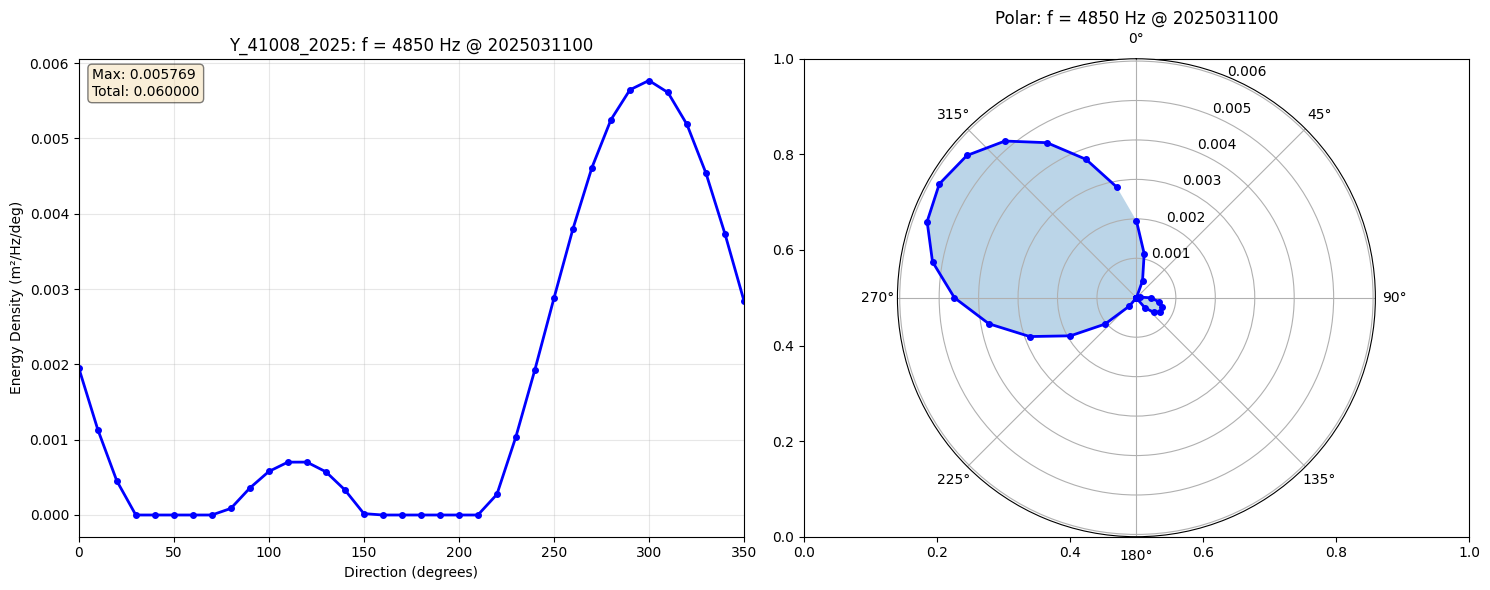


📈 Analysis for f = 4850 Hz:
   Peak direction: 300°
   Energy spread: 0.00203966
   Zero directions: 11/36

🏔️ Top 5 directions with energy:
   1. 300°: 0.00576944
   2. 290°: 0.00564575
   3. 310°: 0.00561018
   4. 280°: 0.00524849
   5. 320°: 0.00518581

✅ Frequency analysis completed!
   This shows the directional spread of wave energy at f = 4850 Hz
   Zero values are physically correct - no waves at that frequency/direction


In [26]:
# 📊 Plot Specific Frequency: Y_41008_2025 for f.4850
# Show directional distribution for a single frequency

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("📊 Plotting Y_41008_2025 for f.4850 across all directions...")

y_data = Y_41008_2025
target_freq = "4850"  # Match the column format f.4850_dir350

print(f"🎯 Dataset: Y_41008_2025")
print(f"   Shape: {y_data.shape}")
print(f"   Target frequency: f.{target_freq} (columns format)")

# Find columns for this frequency across all directions
# Columns are formatted as f.4850_dir000, f.4850_dir010, etc.
freq_cols = [col for col in y_data.columns if col.startswith(f'f.{target_freq}_dir')]

if not freq_cols:
    print(f"❌ No columns found for frequency {target_freq}")
    print("Available frequencies:")
    all_freq_cols = [col for col in y_data.columns if col.startswith('f')]
    freqs = set([col.split('_')[0] for col in all_freq_cols])
    for freq in sorted(list(freqs))[:10]:  # Show first 10
        print(f"   {freq}")
else:
    print(f"✅ Found {len(freq_cols)} direction columns for f = {target_freq}")
    
    # Extract directions from column names
    directions = []
    for col in freq_cols:
        dir_str = col.split('_dir')[1]  # Get direction part
        direction = int(dir_str)
        directions.append(direction)
    
    directions = sorted(directions)
    print(f"   Directions: {directions[0]}° to {directions[-1]}° ({len(directions)} bins)")
    
    # Get data for a specific time step (find one with highest energy)
    freq_data = y_data[freq_cols]
    time_energies = freq_data.sum(axis=1)
    
    print(f"\n🔋 Energy statistics for f = {target_freq}:")
    print(f"   Total energy: {time_energies.sum():.8f}")
    print(f"   Max time energy: {time_energies.max():.8f}")
    print(f"   Non-zero times: {(time_energies > 0).sum()}/{len(time_energies)}")
    
    # Find time with maximum energy for this frequency
    if time_energies.max() > 0:
        max_idx = time_energies.idxmax()
        timekey = y_data.iloc[max_idx]['timekey']
        print(f"   Peak energy time: {timekey}")
        
        # Extract energy values for all directions at peak time
        energy_values = []
        for direction in directions:
            col_name = f"f.{target_freq}_dir{direction:03d}"
            energy = y_data.iloc[max_idx][col_name]
            energy_values.append(energy)
        
        # Create the plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Plot 1: Linear plot - Energy vs Direction
        ax1.plot(directions, energy_values, 'b-o', linewidth=2, markersize=4)
        ax1.set_xlabel('Direction (degrees)')
        ax1.set_ylabel('Energy Density (m²/Hz/deg)')
        ax1.set_title(f'Y_41008_2025: f = {target_freq} Hz @ {timekey}')
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(0, 350)
        
        # Add statistics to plot
        max_energy = max(energy_values)
        total_energy = sum(energy_values)
        ax1.text(0.02, 0.98, f'Max: {max_energy:.6f}\nTotal: {total_energy:.6f}', 
                transform=ax1.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Plot 2: Polar plot - Same data in polar coordinates
        theta_rad = np.deg2rad(directions)
        ax2 = plt.subplot(122, projection='polar')
        ax2.plot(theta_rad, energy_values, 'b-o', linewidth=2, markersize=4)
        ax2.fill(theta_rad, energy_values, alpha=0.3)
        ax2.set_title(f'Polar: f = {target_freq} Hz @ {timekey}')
        ax2.set_theta_direction(-1)  # Clockwise
        ax2.set_theta_zero_location('N')  # 0° at top
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n📈 Analysis for f = {target_freq} Hz:")
        print(f"   Peak direction: {directions[energy_values.index(max_energy)]}°")
        print(f"   Energy spread: {np.std(energy_values):.8f}")
        print(f"   Zero directions: {energy_values.count(0)}/{len(energy_values)}")
        
        # Show top 5 directions with most energy
        dir_energy_pairs = list(zip(directions, energy_values))
        dir_energy_pairs.sort(key=lambda x: x[1], reverse=True)
        print(f"\n🏔️ Top 5 directions with energy:")
        for i, (dir_deg, energy) in enumerate(dir_energy_pairs[:5]):
            if energy > 0:
                print(f"   {i+1}. {dir_deg:3d}°: {energy:.8f}")
    
    else:
        print(f"\n❌ No energy found at f = {target_freq} Hz for any time step")
        print("   This frequency band is completely empty - no waves at this period")
        
        # Still create a plot showing all zeros
        energy_values = [0] * len(directions)
        
        plt.figure(figsize=(12, 5))
        plt.plot(directions, energy_values, 'r-o', linewidth=2, markersize=4)
        plt.xlabel('Direction (degrees)')
        plt.ylabel('Energy Density (m²/Hz/deg)')
        plt.title(f'Y_41008_2025: f = {target_freq} Hz (All Zeros - No Wave Energy)')
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 350)
        plt.ylim(-0.001, 0.001)
        plt.show()

print(f"\n✅ Frequency analysis completed!")
print(f"   This shows the directional spread of wave energy at f = {target_freq} Hz")
print(f"   Zero values are physically correct - no waves at that frequency/direction")

In [27]:
# 🌊 3D Surface Plot: f.4850 Energy across Directions and Time
# Interactive 3D visualization showing wave energy evolution

import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd

print("🌊 Creating 3D surface plot for f.4850 energy distribution...")

y_data = Y_41008_2025
target_freq = "4850"

# Get all f.4850 direction columns
freq_cols = [col for col in y_data.columns if col.startswith(f'f.{target_freq}_dir')]
freq_cols = sorted(freq_cols)  # Ensure proper order

print(f"🎯 Target frequency: f.{target_freq}")
print(f"   Found {len(freq_cols)} direction columns")

if len(freq_cols) > 0:
    # Extract directions from column names
    directions = []
    for col in freq_cols:
        dir_str = col.split('_dir')[1]
        directions.append(int(dir_str))
    
    # Get energy data matrix: [time, direction]
    energy_matrix = y_data[freq_cols].values
    n_times, n_dirs = energy_matrix.shape
    
    print(f"   Energy matrix: {n_times} time steps × {n_dirs} directions")
    print(f"   Time range: {y_data.iloc[0]['timekey']} to {y_data.iloc[-1]['timekey']}")
    
    # Filter to times with significant energy (reduce noise)
    time_energies = energy_matrix.sum(axis=1)
    energy_threshold = np.percentile(time_energies[time_energies > 0], 75)  # Top 25%
    high_energy_mask = time_energies >= energy_threshold
    
    if high_energy_mask.sum() > 0:
        # Use only high-energy time steps for clearer visualization
        filtered_matrix = energy_matrix[high_energy_mask, :]
        filtered_times = y_data[high_energy_mask]['timekey'].values
        
        print(f"   Using {len(filtered_times)} high-energy time steps (≥{energy_threshold:.6f})")
        
        # Sample time steps if too many for visualization
        max_times = 50  # Limit for performance
        if len(filtered_times) > max_times:
            step = len(filtered_times) // max_times
            indices = range(0, len(filtered_times), step)[:max_times]
            filtered_matrix = filtered_matrix[indices, :]
            filtered_times = filtered_times[indices]
            print(f"   Sampled to {len(filtered_times)} time steps for visualization")
        
        # Create coordinate grids
        X = np.array(directions)  # Directions: 0, 10, 20, ..., 350
        Y = np.arange(len(filtered_times))  # Time indices
        XX, YY = np.meshgrid(X, Y)
        ZZ = filtered_matrix
        
        # Create interactive 3D surface plot
        fig = go.Figure(data=[go.Surface(
            x=XX,
            y=YY, 
            z=ZZ,
            colorscale='Viridis',
            name=f'f.{target_freq} Energy',
            hovertemplate='<b>Direction:</b> %{x}°<br>' +
                         '<b>Time Step:</b> %{y}<br>' +
                         '<b>Energy:</b> %{z:.6f}<br>' +
                         '<extra></extra>'
        )])
        
        # Update layout for better visualization
        fig.update_layout(
            title=f'3D Wave Energy Surface: Y_41008_2025 f.{target_freq}Hz',
            scene=dict(
                xaxis_title='Direction (degrees)',
                yaxis_title='Time Steps', 
                zaxis_title='Energy Density (m²/Hz/deg)',
                camera=dict(
                    eye=dict(x=1.5, y=1.5, z=1.2)  # Good viewing angle
                ),
                xaxis=dict(tickmode='linear', tick0=0, dtick=30),  # Every 30°
                yaxis=dict(tickmode='linear', dtick=10),           # Every 10 time steps
            ),
            width=900,
            height=700
        )
        
        fig.show()
        
        # Statistics
        max_energy = np.max(ZZ)
        total_energy = np.sum(ZZ)
        max_pos = np.unravel_index(np.argmax(ZZ), ZZ.shape)
        peak_time_idx, peak_dir_idx = max_pos
        
        print(f"\n📊 3D Surface Statistics:")
        print(f"   Peak energy: {max_energy:.6f} at direction {directions[peak_dir_idx]}°")
        print(f"   Peak time step: {peak_time_idx} ({filtered_times[peak_time_idx]})")
        print(f"   Total energy: {total_energy:.6f}")
        print(f"   Energy std: {np.std(ZZ):.6f}")
        
        # Direction-averaged time series
        time_avg = np.mean(ZZ, axis=1)
        peak_time = np.argmax(time_avg)
        print(f"   Peak time (avg): Step {peak_time} ({filtered_times[peak_time]})")
        
        # Time-averaged directional profile  
        dir_avg = np.mean(ZZ, axis=0)
        peak_dir = np.argmax(dir_avg)
        print(f"   Peak direction (avg): {directions[peak_dir]}°")
        
    else:
        print("❌ No high-energy time steps found for visualization")
        
else:
    print(f"❌ No columns found for frequency {target_freq}")

print(f"\n✅ 3D visualization completed!")
print(f"   Shows wave energy 'mountains' and 'valleys' across directions and time")
print(f"   Interactive: rotate, zoom, hover for details")

🌊 Creating 3D surface plot for f.4850 energy distribution...
🎯 Target frequency: f.4850
   Found 36 direction columns
   Energy matrix: 1791 time steps × 36 directions
   Time range: 2025010104 to 2025123123
   Using 412 high-energy time steps (≥0.020000)
   Sampled to 50 time steps for visualization



📊 3D Surface Statistics:
   Peak energy: 0.003734 at direction 10°
   Peak time step: 38 (2025100311)
   Total energy: 1.140000
   Energy std: 0.000723
   Peak time (avg): Step 1 (2025010709)
   Peak direction (avg): 10°

✅ 3D visualization completed!
   Shows wave energy 'mountains' and 'valleys' across directions and time
   Interactive: rotate, zoom, hover for details


In [28]:
# 💾 Save and Load 2D Wave Spectrum Y Variables
# Persistent storage for Y_{station}_{year} DataFrames

import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import os

def save_Y_data():
    """Save all Y variables to ../data/Y_spectra/ directory"""
    
    print("💾 Saving 2D wave spectrum Y variables...")
    
    # Create Y spectra directory
    y_spectra_dir = Path('../data/Y_spectra')
    y_spectra_dir.mkdir(parents=True, exist_ok=True)
    
    # Find all Y variables in current namespace
    y_variables = {}
    for var_name in globals().keys():
        if var_name.startswith('Y_') and isinstance(globals()[var_name], pd.DataFrame):
            y_variables[var_name] = globals()[var_name]
    
    if not y_variables:
        print("❌ No Y variables found to save!")
        return False
    
    print(f"🎯 Found {len(y_variables)} Y variables to save:")
    
    # Save each Y variable
    saved_count = 0
    failed_count = 0
    total_size_mb = 0
    
    for y_name, y_df in y_variables.items():
        try:
            # Create filename
            filename = f"{y_name}.pkl"
            filepath = y_spectra_dir / filename
            
            # Save to pickle
            y_df.to_pickle(filepath)
            
            # Get file size
            file_size_mb = filepath.stat().st_size / (1024 * 1024)
            total_size_mb += file_size_mb
            
            print(f"  ✅ {y_name}: {y_df.shape} -> {filename} ({file_size_mb:.2f} MB)")
            saved_count += 1
            
        except Exception as e:
            print(f"  ❌ {y_name}: Error - {str(e)}")
            failed_count += 1
    
    print(f"\n✅ Y data saving completed!")
    print(f"   📁 Saved to: {y_spectra_dir.absolute()}")
    print(f"   ✅ Successfully saved: {saved_count}")
    print(f"   ❌ Failed to save: {failed_count}")
    print(f"   💽 Total size: {total_size_mb:.2f} MB")
    
    return saved_count > 0

def load_Y_data():
    """Load all Y variables from ../data/Y_spectra/ directory"""
    
    print("📂 Loading 2D wave spectrum Y variables...")
    
    # Check Y spectra directory
    y_spectra_dir = Path('../data/Y_spectra')
    
    if not y_spectra_dir.exists():
        print(f"❌ Directory not found: {y_spectra_dir}")
        print("   Run save_Y_data() first to create Y spectrum files!")
        return False
    
    # Find all Y pickle files
    y_files = list(y_spectra_dir.glob("Y_*.pkl"))
    
    if not y_files:
        print("❌ No Y pickle files found in directory!")
        return False
    
    print(f"🎯 Found {len(y_files)} Y files to load:")
    
    # Load each Y variable
    loaded_count = 0
    failed_count = 0
    total_size_mb = 0
    loaded_variables = []
    
    for y_file in sorted(y_files):
        try:
            # Extract variable name from filename
            y_name = y_file.stem  # Remove .pkl extension
            
            # Load DataFrame
            y_df = pd.read_pickle(y_file)
            
            # Store in global namespace
            globals()[y_name] = y_df
            
            # Get file size
            file_size_mb = y_file.stat().st_size / (1024 * 1024)
            total_size_mb += file_size_mb
            
            loaded_variables.append(y_name)
            loaded_count += 1
            
            print(f"  ✅ {y_name}: {y_df.shape} ({file_size_mb:.2f} MB)")
            
        except Exception as e:
            failed_count += 1
            print(f"  ❌ {y_file.name}: Error - {str(e)}")
    
    print(f"\n✅ Y data loading completed!")
    print(f"   📁 Loaded from: {y_spectra_dir.absolute()}")
    print(f"   ✅ Successfully loaded: {loaded_count}")
    print(f"   ❌ Failed to load: {failed_count}")
    print(f"   💽 Total size: {total_size_mb:.2f} MB")
    
    # Show summary by station
    if loaded_variables:
        print(f"\n📊 Y Variables loaded:")
        stations = {}
        for y_name in loaded_variables:
            parts = y_name.split('_')
            if len(parts) >= 3:
                station = parts[1]
                year = parts[2]
                if station not in stations:
                    stations[station] = []
                stations[station].append(year)
        
        for station, years in sorted(stations.items()):
            years_str = ', '.join(sorted(years))
            print(f"   Station {station}: {len(years)} years ({years_str})")
        
        print(f"\n🌊 Ready for 2D wave spectrum analysis and machine learning!")
    
    return loaded_count > 0

def check_Y_data():
    """Check current Y variables in memory"""
    
    print("🔍 Checking Y variables in current session...")
    
    y_variables = {}
    for var_name in globals().keys():
        if var_name.startswith('Y_') and isinstance(globals()[var_name], pd.DataFrame):
            y_variables[var_name] = globals()[var_name]
    
    if not y_variables:
        print("❌ No Y variables found in current session!")
        print("   Run load_Y_data() to load from files, or run cell 2 to create them.")
        return False
    
    print(f"✅ Found {len(y_variables)} Y variables in memory:")
    
    total_rows = 0
    stations = {}
    
    for y_name, y_df in sorted(y_variables.items()):
        total_rows += len(y_df)
        print(f"  {y_name}: {y_df.shape}")
        
        # Extract station info
        parts = y_name.split('_')
        if len(parts) >= 3:
            station = parts[1]
            if station not in stations:
                stations[station] = 0
            stations[station] += 1
    
    print(f"\n📊 Summary:")
    for station, count in sorted(stations.items()):
        print(f"   Station {station}: {count} datasets")
    print(f"   Total time records: {total_rows:,}")
    
    return True

# Usage examples:
print("🎯 Y Data Management Functions Available:")
print("   save_Y_data()  - Save all Y variables to files")
print("   load_Y_data()  - Load Y variables from files") 
print("   check_Y_data() - Check Y variables in memory")
print(f"\n📁 Storage location: ../data/Y_spectra/")

# Check current status
check_Y_data()

🎯 Y Data Management Functions Available:
   save_Y_data()  - Save all Y variables to files
   load_Y_data()  - Load Y variables from files
   check_Y_data() - Check Y variables in memory

📁 Storage location: ../data/Y_spectra/
🔍 Checking Y variables in current session...
✅ Found 21 Y variables in memory:
  Y_41008_2006: (739, 1693)
  Y_41008_2007: (8650, 1693)
  Y_41008_2008: (8650, 1693)
  Y_41008_2009: (3250, 1693)
  Y_41008_2013: (8041, 1693)
  Y_41008_2014: (8406, 1693)
  Y_41008_2015: (8644, 1693)
  Y_41008_2016: (6151, 1693)
  Y_41008_2017: (8583, 1693)
  Y_41008_2018: (8613, 1693)
  Y_41008_2019: (8586, 1693)
  Y_41008_2020: (8580, 1693)
  Y_41008_2021: (8490, 1693)
  Y_41008_2022: (8655, 1693)
  Y_41008_2023: (5322, 1693)
  Y_41008_2024: (1825, 1693)
  Y_41008_2025: (1791, 1693)
  Y_51028_2005: (6787, 1693)
  Y_51028_2006: (7073, 1693)
  Y_51028_2007: (2962, 1693)
  Y_51028_2008: (2507, 1693)

📊 Summary:
   Station 41008: 17 datasets
   Station 51028: 4 datasets
   Total time r

True

In [29]:
save_Y_data()

💾 Saving 2D wave spectrum Y variables...
🎯 Found 21 Y variables to save:
  ✅ Y_41008_2006: (739, 1693) -> Y_41008_2006.pkl (9.68 MB)
  ✅ Y_41008_2007: (8650, 1693) -> Y_41008_2007.pkl (111.91 MB)
  ✅ Y_41008_2008: (8650, 1693) -> Y_41008_2008.pkl (111.91 MB)
  ✅ Y_41008_2009: (3250, 1693) -> Y_41008_2009.pkl (42.13 MB)
  ✅ Y_41008_2013: (8041, 1693) -> Y_41008_2013.pkl (104.03 MB)
  ✅ Y_41008_2014: (8406, 1693) -> Y_41008_2014.pkl (108.76 MB)
  ✅ Y_41008_2015: (8644, 1693) -> Y_41008_2015.pkl (111.83 MB)
  ✅ Y_41008_2016: (6151, 1693) -> Y_41008_2016.pkl (79.61 MB)
  ✅ Y_41008_2017: (8583, 1693) -> Y_41008_2017.pkl (111.04 MB)
  ✅ Y_41008_2018: (8613, 1693) -> Y_41008_2018.pkl (111.43 MB)
  ✅ Y_41008_2019: (8586, 1693) -> Y_41008_2019.pkl (111.08 MB)
  ✅ Y_41008_2020: (8580, 1693) -> Y_41008_2020.pkl (111.01 MB)
  ✅ Y_41008_2021: (8490, 1693) -> Y_41008_2021.pkl (109.84 MB)
  ✅ Y_41008_2022: (8655, 1693) -> Y_41008_2022.pkl (111.97 MB)
  ✅ Y_41008_2023: (5322, 1693) -> Y_41008_2023.pkl

True